# Modeling

Training CNN architectures on the augmented OCT volume dataset using memory-efficient `tf.data.Dataset` pipelines.

## Imports

In [1]:
import sys
sys.path.append('..')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TF info/warnings

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from octcv.mdl_lib import yX_split, XVolSet, ModelEvaluator, train_model
from octcv.mdl_lib.architectures import buildSequential, buildResNet, buildAttnNN
from octcv.mdl_lib.callbacks import LivePlot
from octcv.system_monitoring import startMemoryMonitor

In [2]:
startMemoryMonitor()

## Load & Split Data

Load the augmented metadata CSV and apply the same train/test split from Capstone 2.

In [3]:
# Load augmented metadata
aug_df = pd.read_csv('../datasrc/volumeOCT-AUGMENTED_metadata.csv')
print(f"Augmented dataset: {len(aug_df)} entries")
print(f"Augmentations: {aug_df['augmentation'].unique()}")

# Load original train/test splits
v_train = pd.read_csv('../p5_Modeling/volumes_train.csv')
v_test = pd.read_csv('../p5_Modeling/volumes_TEST.csv')

Augmented dataset: 6660 entries
Augmentations: ['original' 'dark' 'bright' 'noise' 'lpf' 'fan']


In [4]:
# Pivot augmented data: one row per original volume, columns per augmentation type
nonpath_columns = ['dx_class', 'glaucoma', 'PIN', 'laterality', 'left_eye', 'set']
augmentations = aug_df['augmentation'].unique()

augpiv = aug_df.pivot(
    index=nonpath_columns,
    columns='augmentation',
    values='display_volume'
).rename_axis(None, axis=1).reset_index()

# Merge with train split and melt back to long format
augpiv_train = pd.merge(
    v_train, augpiv[list(augmentations)],
    left_on='display_volume', right_on='original', how='left'
).drop(columns='display_volume')

augTRAIN = pd.melt(
    augpiv_train, id_vars=nonpath_columns,
    var_name='augmentation', value_vars=augmentations,
    value_name='display_volume'
)

# Same for test split
augpiv_test = pd.merge(
    v_test, augpiv[list(augmentations)],
    left_on='display_volume', right_on='original', how='left'
).drop(columns='display_volume')

augTEST = pd.melt(
    augpiv_test, id_vars=nonpath_columns,
    var_name='augmentation', value_vars=augmentations,
    value_name='display_volume'
)

# Split test into validation + evaluation
augVALID, augEVAL = train_test_split(augTEST, test_size=0.5, random_state=42)

print(f"Train: {len(augTRAIN)} | Valid: {len(augVALID)} | Eval: {len(augEVAL)}")

Train: 5328 | Valid: 666 | Eval: 666


## Create tf.data.Dataset Pipelines

Using `XVolSet.to_tf_dataset()` — volumes are loaded lazily in batches, never all at once.

In [5]:
# Split into y (labels) and X (XVolSet wrapping file paths)
_, ay_train, aX_train = yX_split(augTRAIN, display_filepath_columns='display_volume')
_, ay_valid, aX_valid = yX_split(augVALID, display_filepath_columns='display_volume')
_, ay_eval, aX_eval = yX_split(augEVAL, display_filepath_columns='display_volume')

BATCH_SIZE = 4

print(f"Input shape: {aX_train.input_shape}")
print(f"Batches per epoch (train): ~{len(aX_train) // BATCH_SIZE}")

Input shape: (64, 128, 64, 1)
Batches per epoch (train): ~1332


## Model 1: Sequential CNN

In [6]:
model_seq = buildSequential()
model_seq.summary()

I0000 00:00:1780618525.469189 2236128 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9899 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "original_sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ BLOCK1_Conv3D (Conv3D)          │ (None, 32, 64, 32, 32) │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK1_BatchNorm                │ (None, 32, 64, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK1_ReLU (ReLU)              │ (None, 32, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK2_Conv3D (Conv3D)          │ (None, 32, 64, 32, 32) │       128,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK2_BatchNorm                │ (None, 32, 64, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK2_ReLU (ReLU)              │ (None, 32, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK3_Conv3D (Conv3D)          │ (None, 32, 64, 32, 32) │       128,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK3_BatchNorm                │ (None, 32, 64, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK3_ReLU (ReLU)              │ (None, 32, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK4_Conv3D (Conv3D)          │ (None, 32, 64, 32, 32) │        27,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK4_BatchNorm                │ (None, 32, 64, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK4_ReLU (ReLU)              │ (None, 32, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK5_Conv3D (Conv3D)          │ (None, 32, 64, 32, 32) │        27,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK5_BatchNorm                │ (None, 32, 64, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK5_ReLU (ReLU)              │ (None, 32, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePooling3D          │ (None, 32)             │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,105 (1.23 MB)

 Trainable params: 322,785 (1.23 MB)

 Non-trainable params: 320 (1.25 KB)

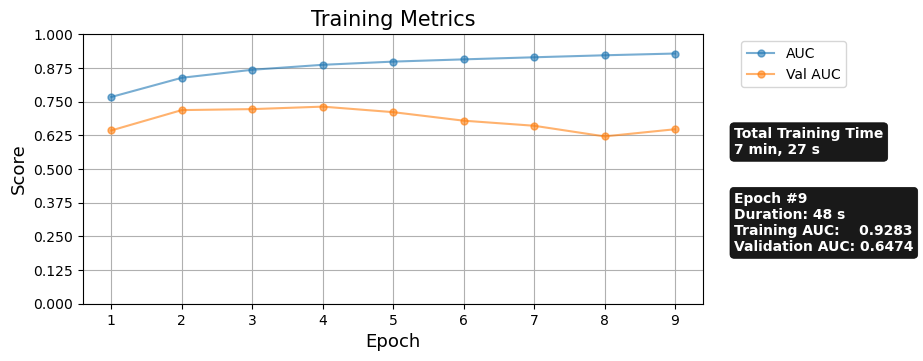

In [7]:
# Create fresh datasets (generators are single-use)
train_ds = aX_train.to_tf_dataset(ay_train, batch_size=BATCH_SIZE)
valid_ds = aX_valid.to_tf_dataset(ay_valid, batch_size=BATCH_SIZE)

history_seq = train_model(
    model_seq, train_ds, valid_ds,
    epochs=50,
    patience=5,
    learning_rate=1e-4,
    live_plot=True,
    metrics_to_plot=['auc', 'val_auc']
)

/home/etudie/PROJECTS/OCTCV/PART_2/../octcv/mdl_lib/__init__.py:669: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


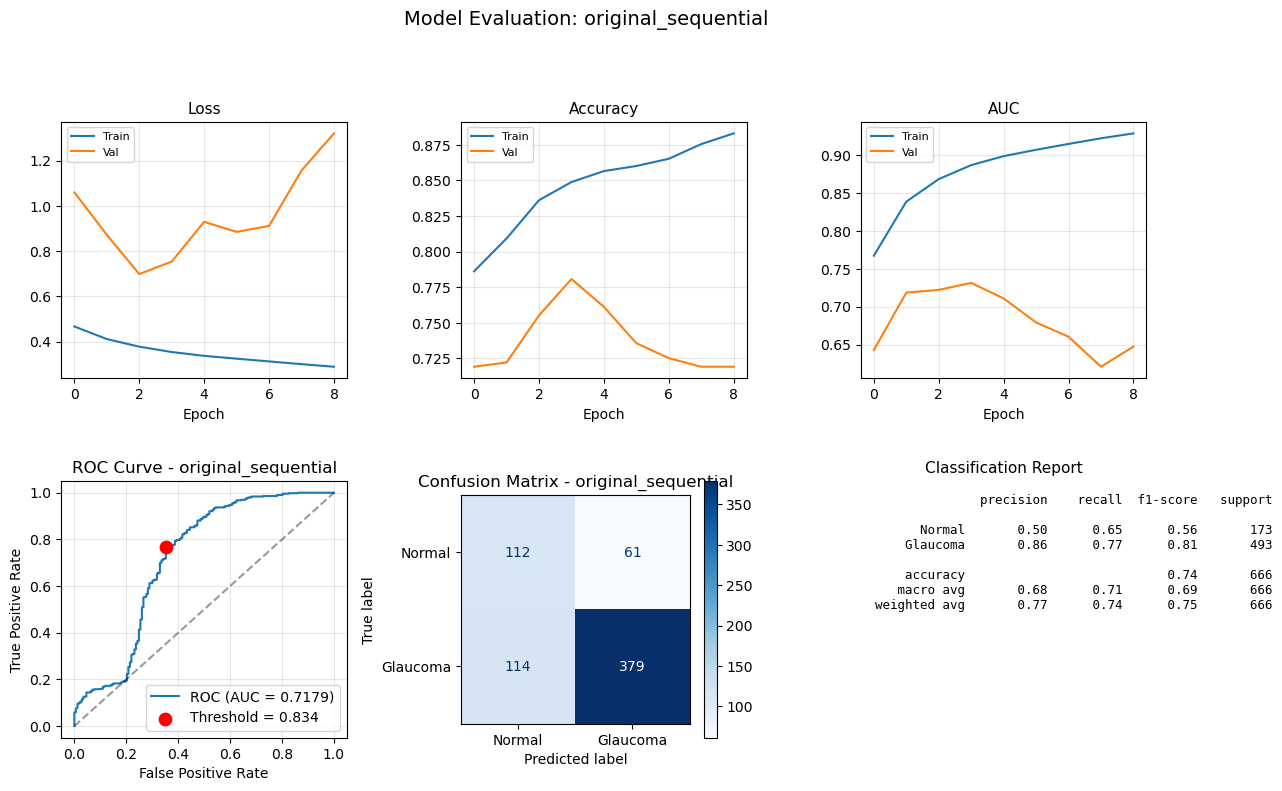


AUC: 0.7179 | Threshold: 0.8336


In [8]:
# Evaluate
eval_ds = aX_eval.to_tf_dataset(ay_eval, batch_size=BATCH_SIZE)
evaluator_seq = ModelEvaluator(model_seq, history_seq, eval_ds)
evaluator_seq.summary()

## Model 2: ResNet-Like

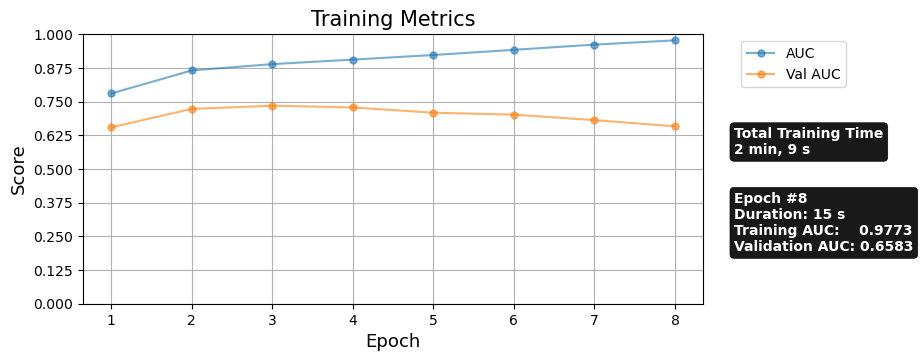

In [9]:
model_res = buildResNet()

train_ds = aX_train.to_tf_dataset(ay_train, batch_size=BATCH_SIZE)
valid_ds = aX_valid.to_tf_dataset(ay_valid, batch_size=BATCH_SIZE)

history_res = train_model(
    model_res, train_ds, valid_ds,
    epochs=50,
    patience=5,
    learning_rate=1e-4,
    live_plot=True
)

/home/etudie/PROJECTS/OCTCV/PART_2/../octcv/mdl_lib/__init__.py:669: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


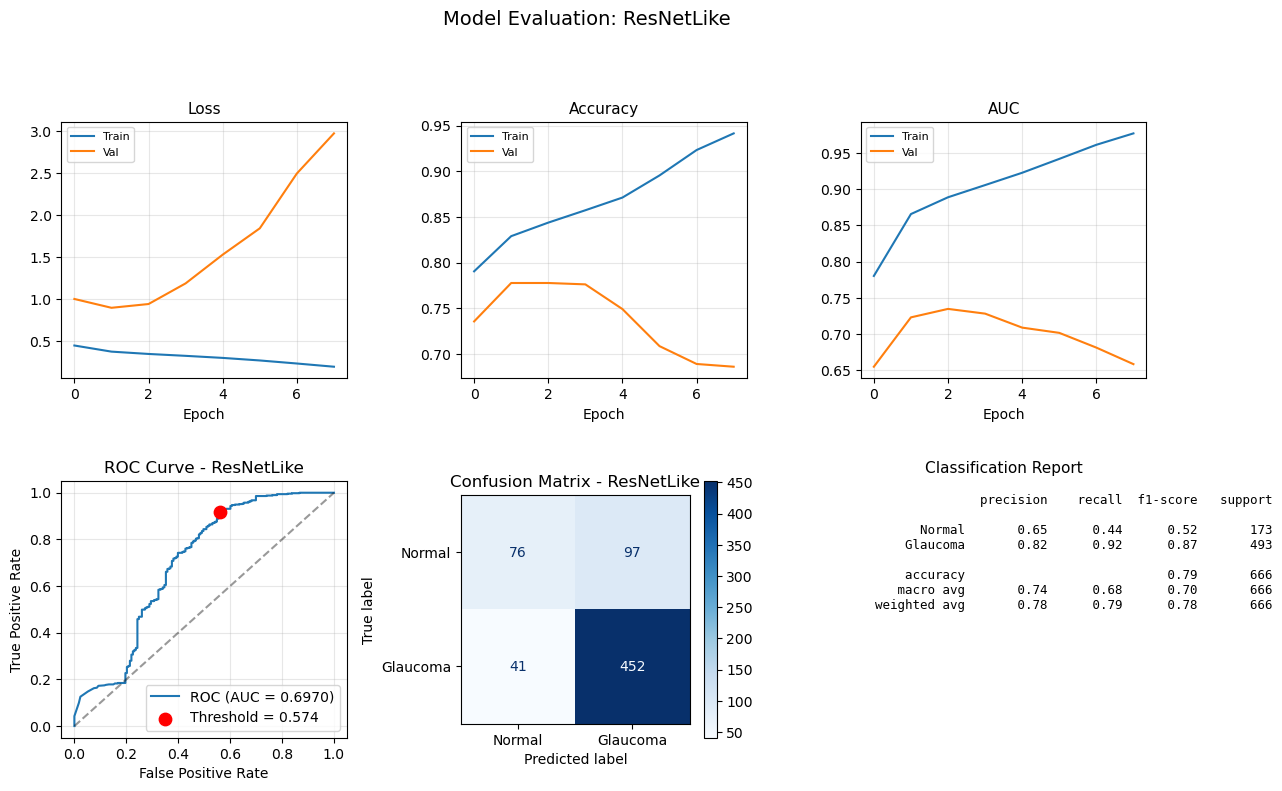


AUC: 0.6970 | Threshold: 0.5737


In [10]:
eval_ds = aX_eval.to_tf_dataset(ay_eval, batch_size=BATCH_SIZE)
evaluator_res = ModelEvaluator(model_res, history_res, eval_ds)
evaluator_res.summary()

## Model 3: Attention Network

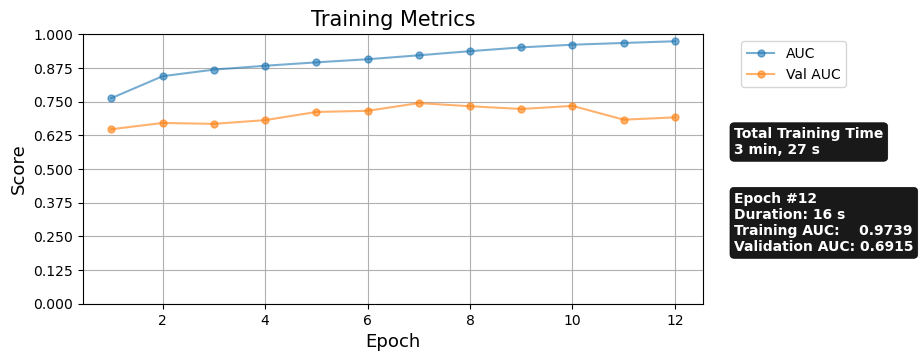

In [11]:
model_attn = buildAttnNN()

train_ds = aX_train.to_tf_dataset(ay_train, batch_size=BATCH_SIZE)
valid_ds = aX_valid.to_tf_dataset(ay_valid, batch_size=BATCH_SIZE)

history_attn = train_model(
    model_attn, train_ds, valid_ds,
    epochs=50,
    patience=5,
    learning_rate=1e-4,
    live_plot=True
)

/home/etudie/PROJECTS/OCTCV/PART_2/../octcv/mdl_lib/__init__.py:669: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


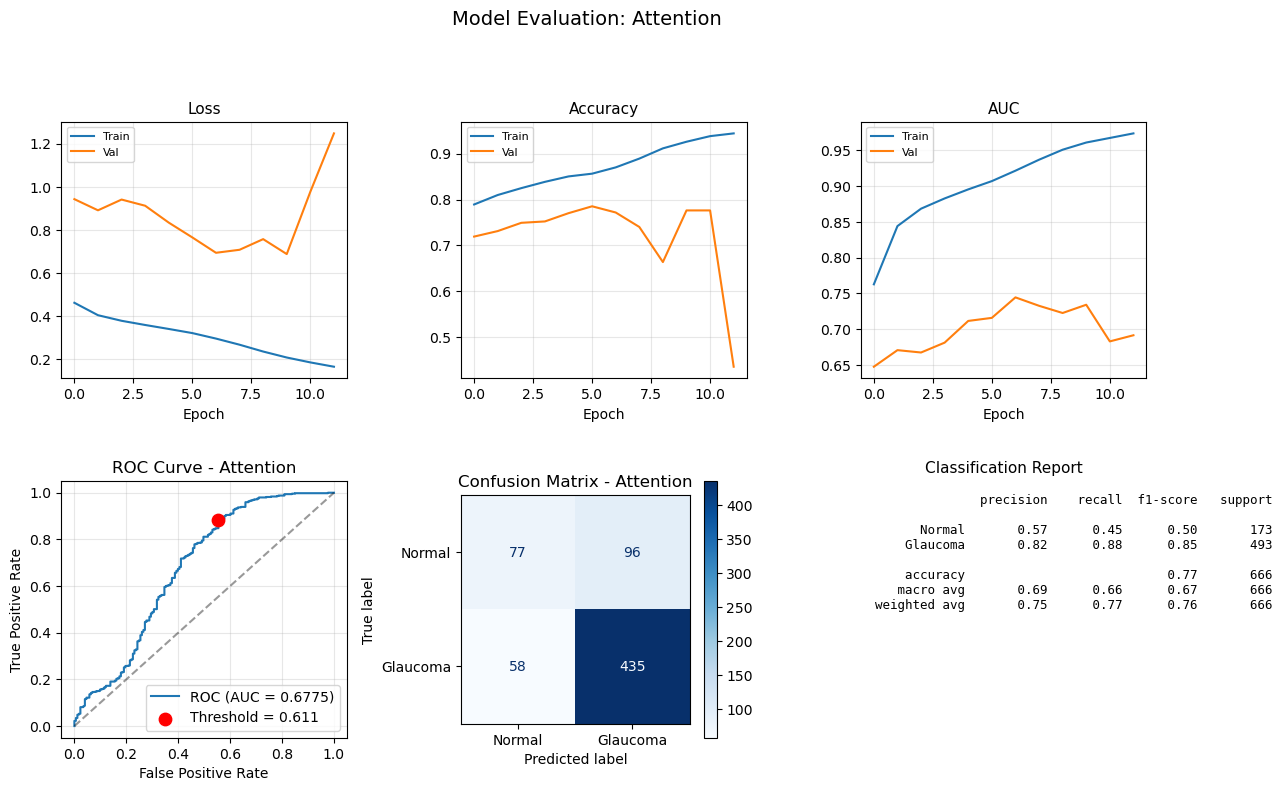


AUC: 0.6775 | Threshold: 0.6107


In [12]:
eval_ds = aX_eval.to_tf_dataset(ay_eval, batch_size=BATCH_SIZE)
evaluator_attn = ModelEvaluator(model_attn, history_attn, eval_ds)
evaluator_attn.summary()

## Model Comparison

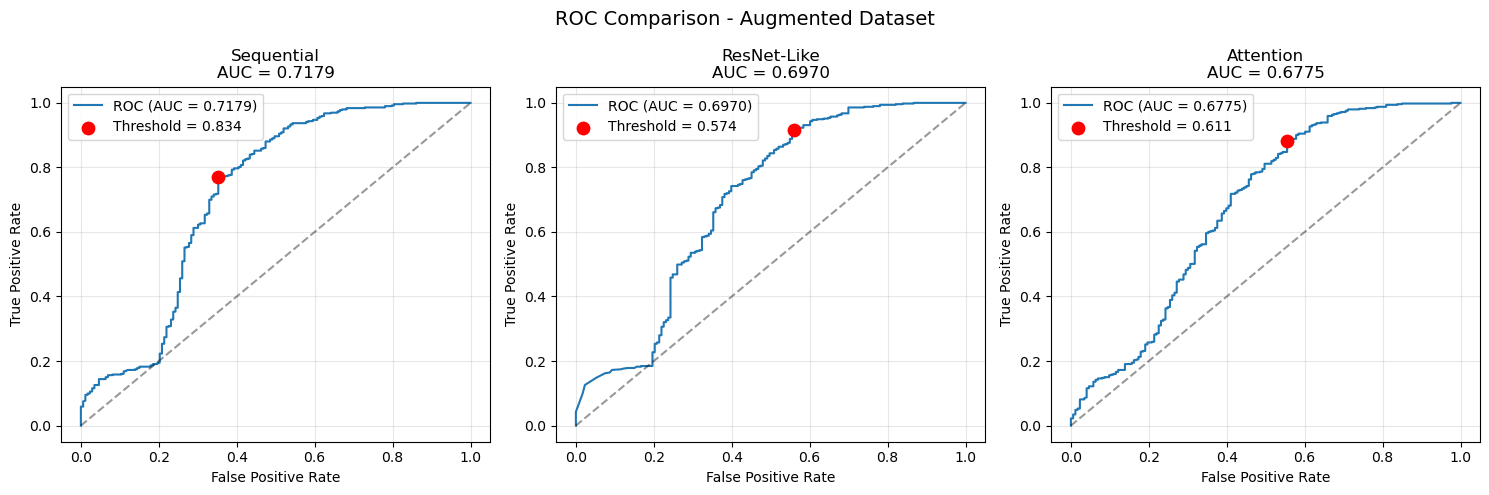


Model           AUC      Threshold   
-----------------------------------
Sequential      0.7179   0.8336
ResNet-Like     0.6970   0.5737
Attention       0.6775   0.6107


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_data = [
    (evaluator_seq, 'Sequential'),
    (evaluator_res, 'ResNet-Like'),
    (evaluator_attn, 'Attention'),
]

for ax, (ev, name) in zip(axes, models_data):
    ev.plot_roc(ax=ax)
    ax.set_title(f'{name}\nAUC = {ev.roc_auc():.4f}')

plt.suptitle('ROC Comparison - Augmented Dataset', fontsize=14)
plt.tight_layout()
plt.show()

# Comparison table
print(f"\n{'Model':<15} {'AUC':<8} {'Threshold':<12}")
print('-' * 35)
for ev, name in models_data:
    print(f"{name:<15} {ev.roc_auc():.4f}   {ev.threshold:.4f}")

## Hyperparameter Tuning

Grid search over learning rates using the best-performing architecture.

In [14]:
learning_rates = [5e-5, 1e-4, 3e-4, 5e-4]
results = []

for lr in learning_rates:
    print(f"\nLR = {lr}")
    model = buildSequential(model_name=f'seq_lr{lr}')

    train_ds = aX_train.to_tf_dataset(ay_train, batch_size=BATCH_SIZE)
    valid_ds = aX_valid.to_tf_dataset(ay_valid, batch_size=BATCH_SIZE)

    history = train_model(
        model, train_ds, valid_ds,
        epochs=30, patience=4, learning_rate=lr, verbose=2
    )

    eval_ds = aX_eval.to_tf_dataset(ay_eval, batch_size=BATCH_SIZE)
    ev = ModelEvaluator(model, history, eval_ds)
    auc = ev.roc_auc()
    results.append({'lr': lr, 'auc': auc, 'epochs': len(history.history['loss'])})
    print(f"  AUC: {auc:.4f} in {results[-1]['epochs']} epochs")


LR = 5e-05
Training: seq_lr5e-05_sequential | Started: 2026-06-04 20:28:54
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Epoch 1/30


2026-06-04 20:29:44.969338: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4989778957424490177
2026-06-04 20:29:44.969404: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6851281237473330736
/home/etudie/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1332/1332 - 53s - 39ms/step - accuracy: 0.7982 - auc: 0.7849 - loss: 0.4519 - val_accuracy: 0.7613 - val_auc: 0.6604 - val_loss: 0.8979
Epoch 2/30


2026-06-04 20:29:47.318303: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4989778957424490177
2026-06-04 20:29:47.318319: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6851281237473330736
2026-06-04 20:30:34.984074: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4989778957424490177
2026-06-04 20:30:34.984135: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6851281237473330736


1332/1332 - 49s - 37ms/step - accuracy: 0.8236 - auc: 0.8534 - loss: 0.3977 - val_accuracy: 0.7763 - val_auc: 0.6871 - val_loss: 0.8076
Epoch 3/30


...

1332/1332 - 50s - 37ms/step - accuracy: 0.8632 - auc: 0.9097 - loss: 0.3106 - val_accuracy: 0.6607 - val_auc: 0.7215 - val_loss: 1.4393
Epoch 7/30
1332/1332 - 49s - 37ms/step - accuracy: 0.8763 - auc: 0.9202 - loss: 0.2937 - val_accuracy: 0.4174 - val_auc: 0.6954 - val_loss: 1.9154
Epoch 8/30


2026-06-04 20:55:50.812158: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4989778957424490177
2026-06-04 20:55:50.812215: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6851281237473330736


1332/1332 - 49s - 37ms/step - accuracy: 0.8842 - auc: 0.9302 - loss: 0.2764 - val_accuracy: 0.4640 - val_auc: 0.6366 - val_loss: 1.8434


2026-06-04 20:56:40.148990: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4989778957424490177
2026-06-04 20:56:40.149054: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6851281237473330736


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finished: 2026-06-04 20:56:40 | Duration: 0:06:38.271602
  AUC: 0.7451 in 8 epochs


In [15]:
results_df = pd.DataFrame(results).sort_values('auc', ascending=False)
print("Hyperparameter Tuning Results:")
print(results_df.to_string(index=False))

best_lr = results_df.iloc[0]['lr']
print(f"\nBest learning rate: {best_lr}")

Hyperparameter Tuning Results:
     lr      auc  epochs
0.00050 0.745114       8
0.00030 0.741614       8
0.00005 0.710947       7
0.00010 0.694298      10

Best learning rate: 0.0005


## Final Training

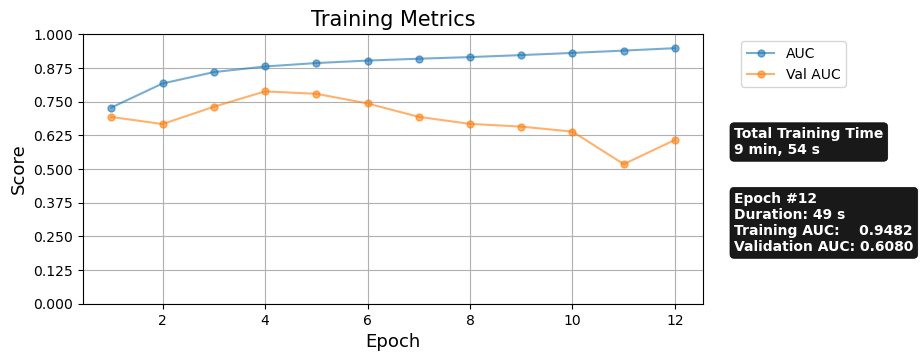

In [16]:
final_model = buildSequential(model_name='final_augmented')

train_ds = aX_train.to_tf_dataset(ay_train, batch_size=BATCH_SIZE)
valid_ds = aX_valid.to_tf_dataset(ay_valid, batch_size=BATCH_SIZE)

final_history = train_model(
    final_model, train_ds, valid_ds,
    epochs=80, patience=8,
    learning_rate=best_lr,
    live_plot=True
)

/home/etudie/PROJECTS/OCTCV/PART_2/../octcv/mdl_lib/__init__.py:669: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


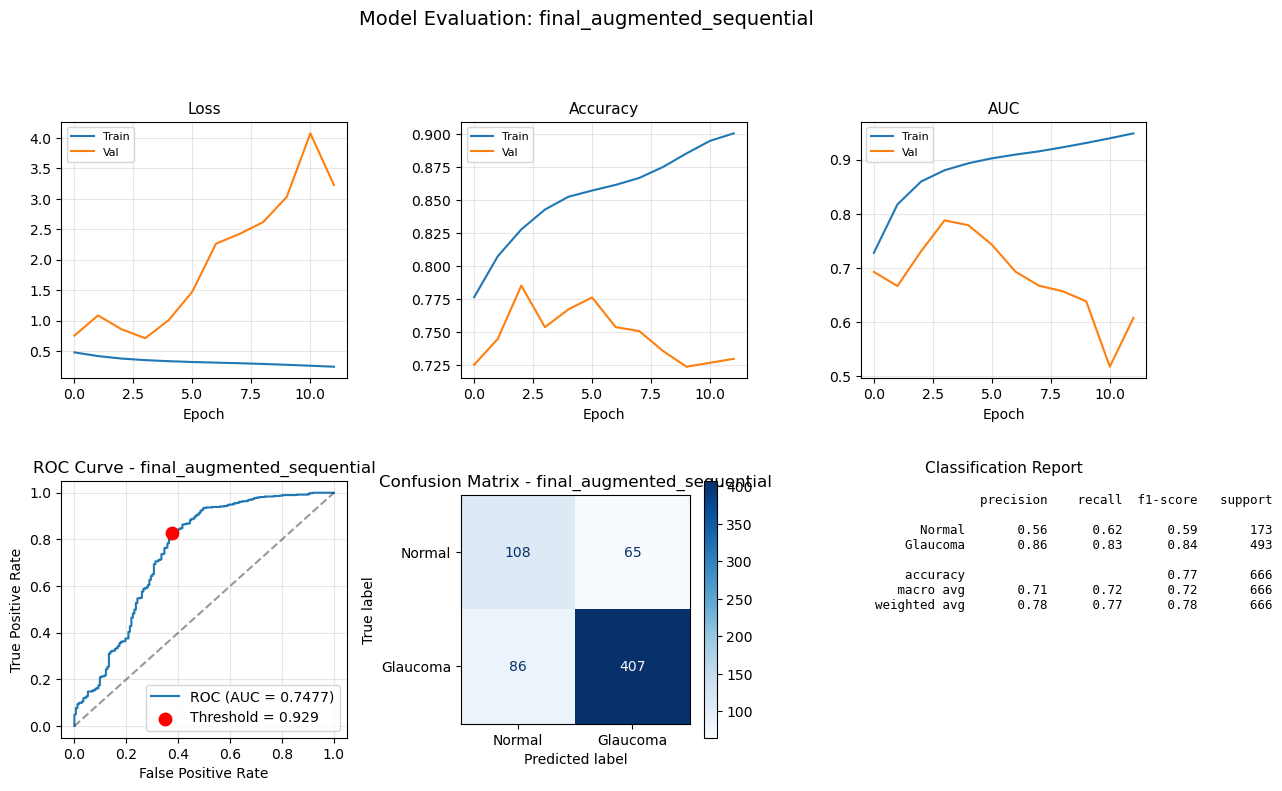


AUC: 0.7477 | Threshold: 0.9294


In [17]:
eval_ds = aX_eval.to_tf_dataset(ay_eval, batch_size=BATCH_SIZE)
final_evaluator = ModelEvaluator(final_model, final_history, eval_ds)
final_evaluator.summary()

## Save Model

In [ ]:
save_dir = os.path.join('..', 'p5_Modeling', 'models', 'augmented_final')
os.makedirs(save_dir, exist_ok=True)
final_model.save(os.path.join(save_dir, 'augmented_final.keras'))
print(f"Model saved to: {save_dir}")